**IDENTIFY DRIVER DROWSINESS THROUGH FACE EXPRESSION**

This command installs all required libraries listed in `requirements.txt`.  
The `-q` flag runs the installation in quiet mode (less verbose output).


In [1]:
# !python3 -m pip install -r requirements.txt -q

- **NumPy**: numerical computations, array manipulation.  
- **Pandas**: tabular data handling (not heavily used here).  
- **os**: file and directory operations.


In [2]:
import numpy as np 
import pandas as pd 
import os

# Importing dependencies

- **TensorFlow**: main deep learning framework.  
- **OpenCV (cv2)**: image reading and processing.  
- **Matplotlib.pyplot**: data visualization and plotting.  
- **ImageDataGenerator**: generates image batches with preprocessing and augmentation.  
- **layers, models (Keras)**: building CNN models.


In [3]:
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers , models

I0000 00:00:1773810494.808343   41844 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773810494.939293   41844 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/fabyanbui/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
I0000 00:00:1773810498.360505   41844 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Viewing image paths and directories

- Specify the directories for **training** and **testing** datasets.  
- Use `os.listdir()` to list the subfolders (e.g., `DROWSY`, `NATURAL`).  
- Print the directory path for verification.


In [4]:
train_data_dir = os.path.join('../Drowsy_dataset/train')
test_data_dir = os.path.join('../Drowsy_dataset/test')
training_files = os.listdir(train_data_dir)
testing_files = os.listdir(test_data_dir)
print(f"Training data directory : ", train_data_dir)
print(f"Testing data directory : ", test_data_dir)
print(f"Training data files: ", training_files)
print(f"Testing data files : ", testing_files)

Training data directory :  ../Drowsy_dataset/train
Testing data directory :  ../Drowsy_dataset/test
Training data files:  ['DROWSY', 'NATURAL']
Testing data files :  ['DROWSY', 'NATURAL']


- Define the paths for the two classes:  
  - **DROWSY**: images of drowsy state.  
  - **NATURAL**: images of normal state.  
- Collect the filenames of images in each class.


In [5]:
train_drowsy_image_path = os.path.join(train_data_dir , 'DROWSY')
train_natural_image_path = os.path.join(train_data_dir, 'NATURAL')
train_drowsy_images= os.listdir(train_drowsy_image_path)
train_natural_images= os.listdir(train_natural_image_path)

test_drowsy_image_path = os.path.join(test_data_dir , 'DROWSY')
test_natural_image_path = os.path.join(test_data_dir, 'NATURAL')
test_drowsy_images= os.listdir(test_drowsy_image_path)
test_natural_images= os.listdir(test_natural_image_path)

print(" Number of files in the training dataset as per class")
print(f" Number of image files in the DROWSY train folder : {len(train_drowsy_images)}")
print(f" Number of image files in the NATURAL test folder : {len(train_natural_images)} ")
print("\n Number of files in the testing dataset as per class ")
print(f" Number of image files in the DROWSY train folder : {len(test_drowsy_images)}")
print(f" Number of image files in the NATURAL test folder : {len(test_natural_images)} ")

 Number of files in the training dataset as per class
 Number of image files in the DROWSY train folder : 2809
 Number of image files in the NATURAL test folder : 3050 

 Number of files in the testing dataset as per class 
 Number of image files in the DROWSY train folder : 757
 Number of image files in the NATURAL test folder : 726 


- Read one image from the **DROWSY** class.  
- Get its dimensions `(height, width, channels)`.  
- Display the image using Matplotlib.  
- Print its shape for verification.


(48, 48, 3)


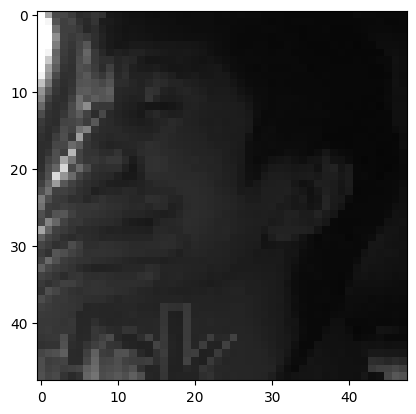

In [6]:
img = cv2.imread(os.path.join(train_drowsy_image_path, train_drowsy_images[0]))
hight, width, channels = img.shape
plt.imshow(img)
print(img.shape)

# Visualizing the the data images

- Create a 4×5 grid of subplots.  
- Display several images from both classes:  
  - First 5 images from **DROWSY**.  
  - Next 5 images from **NATURAL**.  
- Add class titles for clarity.  
- Purpose: visually inspect dataset samples.


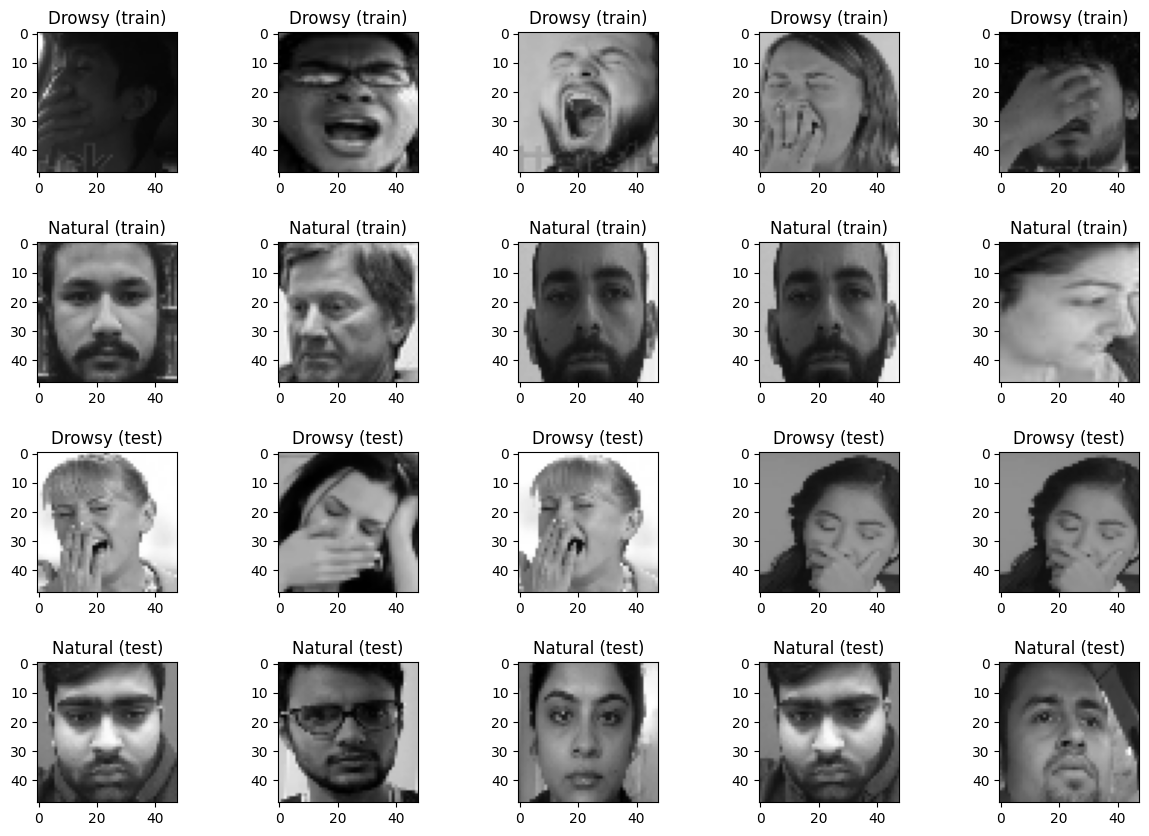

In [7]:
fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for i, axes in enumerate(axes.flat):
    if i < 5:
        img = cv2.imread(os.path.join(train_drowsy_image_path, train_drowsy_images[i]))
        axes.imshow(img)
        axes.set_title('Drowsy (train)')
    if i > 4 and i < 10:
        img = cv2.imread(os.path.join(train_natural_image_path, train_natural_images[i]))
        axes.imshow(img)
        axes.set_title('Natural (train)')
    if i > 9 and i < 15:
        img = cv2.imread(os.path.join(test_drowsy_image_path, test_drowsy_images[i]))
        axes.imshow(img)
        axes.set_title('Drowsy (test)')
    if i > 14 and i < 20:
        img = cv2.imread(os.path.join(test_natural_image_path, test_natural_images[i]))
        axes.imshow(img)
        axes.set_title('Natural (test)')
plt.subplots_adjust(hspace=0.5)
plt.show()

# Splitting the data into Training , Testing and Vallidation set

- Use **ImageDataGenerator** to:  
  - Normalize pixel values to `[0,1]`.  
  - Split dataset into training (80%) and validation (20%).  
  - Apply augmentation: rotation, shift, zoom, horizontal flip.  
- Create three generators:  
  - **train_data_gen**: training set (with augmentation).  
  - **val_data_gen**: validation set (with augmentation).  
  - **test_data_gen**: testing set (only rescaling, no augmentation).


In [8]:
data_generator = ImageDataGenerator(
    rescale = 1./255.0,
    validation_split = 0.2,
    rotation_range=20, # data augmentation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_data_generator = ImageDataGenerator(
    rescale= 1./255.0,
)

train_data_gen = data_generator.flow_from_directory(
    train_data_dir,
    target_size=(48,48),
    class_mode='binary',
    batch_size= 32,
    subset='training',
    shuffle=True
)

val_data_gen = data_generator.flow_from_directory(
    train_data_dir,
    target_size=(48,48),
    class_mode='binary',
    batch_size=32,
    subset='validation',
    shuffle=True
)

test_data_gen = test_data_generator.flow_from_directory(
    test_data_dir,
    target_size = (48,48),
    class_mode = 'binary',
    batch_size = 32,
    shuffle=True
)

Found 4688 images belonging to 2 classes.
Found 1171 images belonging to 2 classes.
Found 1483 images belonging to 2 classes.


- Print the number of samples in training and testing sets.  
- Show the mapping between class labels and indices  
  (e.g., `{'DROWSY': 0, 'NATURAL': 1}`).


In [9]:
print(f"Training data samples :  {train_data_gen.samples} {train_data_gen.class_indices}")
print(f"Testing data samples : {test_data_gen.samples} {test_data_gen.class_indices}")

Training data samples :  4688 {'DROWSY': 0, 'NATURAL': 1}
Testing data samples : 1483 {'DROWSY': 0, 'NATURAL': 1}


# Constructing the neural network

- Sequential model with layers stacked linearly.  
- Architecture:  
  - **Conv2D(32, (3,3), relu)**: convolutional feature extractor.  
  - **MaxPooling2D(2,2)**: downsampling.  
  - **Flatten**: convert 2D features into a 1D vector.  
  - **Dense(128, relu)**: fully connected layer.  
  - **Dense(2, softmax)**: output layer for 2 classes.


In [10]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/home/fabyanbui/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773810504.475466   41844 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773810504.476365   42017 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773810504.502539   41844 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would l

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,083,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,417 (4.14 MB)

 Trainable params: 1,084,417 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

# Training the model

- Use `model.fit()` to train the CNN.  
- Parameters:  
  - `steps_per_epoch`: batches per epoch.  
  - `epochs=10`: train for 10 iterations over the dataset.  
  - `validation_data`: validation set for performance check.  
- Training history is stored in `history`.


In [11]:
history = model.fit(
    train_data_gen,
    steps_per_epoch= train_data_gen.samples // train_data_gen.batch_size,
    epochs=10,
    validation_data = val_data_gen,
    validation_steps = val_data_gen.samples // val_data_gen.batch_size
)

Epoch 1/10


I0000 00:00:1773810505.138348   41844 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


146/146 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 0.6632 - loss: 0.6227 - val_accuracy: 0.5043 - val_loss: 0.7620
Epoch 2/10
  1/146 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7812 - loss: 0.5369

/home/fabyanbui/.local/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7812 - loss: 0.5369 - val_accuracy: 0.5017 - val_loss: 0.7754
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.7350 - loss: 0.5356 - val_accuracy: 0.5434 - val_loss: 0.7745
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6250 - loss: 0.5459 - val_accuracy: 0.5538 - val_loss: 0.7904
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.7556 - loss: 0.5048 - val_accuracy: 0.6085 - val_loss: 0.6991
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7500 - loss: 0.4621 - val_accuracy: 0.5911 - val_loss: 0.7056
Epoch 7/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7839 - loss: 0.4704 - val_accuracy: 0.5972 - val_loss: 0.7270
Epoch 8/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8125 - loss: 0.4065 - val_accuracy: 0.5868 - val_loss: 0.7596
Epoch 9/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.7955 - loss: 0.4473 - val_accuracy: 

# Visualizing the training results

- Plot loss curves for training and validation over epochs.  
- Used to check convergence and detect overfitting.


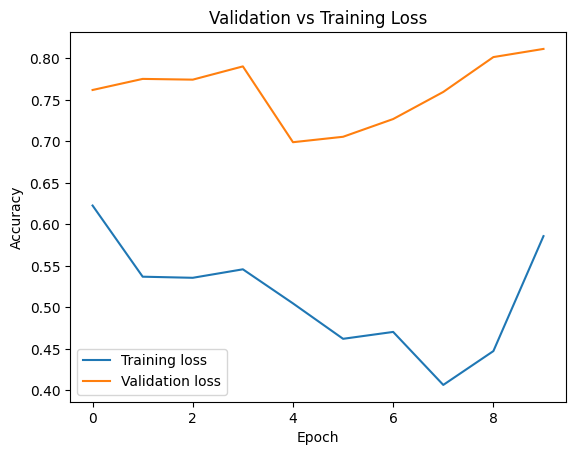

In [12]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation vs Training Loss')
plt.legend()
plt.show()

- Plot accuracy curves for training and validation sets.  
- Compare learning performance across epochs.


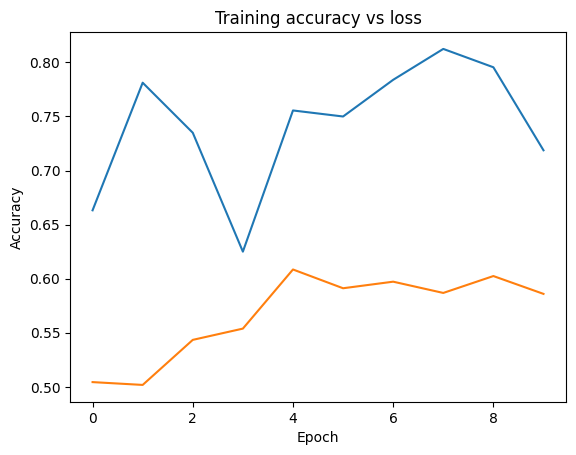

In [13]:
plt.plot(history.history['accuracy'], label='Validation accuracy')
plt.plot(history.history['val_accuracy'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Training accuracy vs loss")
plt.show()

# Testing the model on the test dataset

- Use `model.evaluate()` on the test dataset.  
- Returns final **loss** and **accuracy** on unseen data.


In [14]:
loss , accuracy = model.evaluate(test_data_gen)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8112 - loss: 0.4162


- Print the last training loss and accuracy (from `history`).  
- Print the test loss and accuracy (from `model.evaluate()`).  
- Provides the final model performance summary.


In [15]:
print(f"The training loss is : {history.history['loss'][-1]}")
print(f"The testing loss is : {loss}")

print(f"Training accuracy is : {history.history['accuracy'][-1]}")
print(f"Testing accuracy is : {accuracy}")

The training loss is : 0.5858476161956787
The testing loss is : 0.4161956310272217
Training accuracy is : 0.71875
Testing accuracy is : 0.8111935257911682
